##
Import Library

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine


##
Connecting to Database

In [2]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


##
Analysis Data

>> Retrive data

>>>"The analysis utilizes transaction data from 2022 to 2024. Data records were only available until early 2025; therefore, 2025 data was excluded to maintain consistency and ensure a fair comparison across complete yearly periods."

In [4]:
transaction = ''' 
                SELECT *
                FROM transactions
                WHERE DATE_PART('year',deal_date) <> 2025'''
df_transaction = pd.read_sql(transaction,conn)
df_transaction.head()

,transaction_id,listing_id,property_id,agent_id,customer_id,city,deal_date,deal_price,commission_amount,payment_mode,deal_status
0,T00000001,L0004979,P004474,A00179,C000275,Dhaka,2024-10-20,20951990.0,530085.0,Cash,Completed
1,T00000002,L0001009,P002023,A00059,C004923,Dhaka,2023-09-07,10704517.0,294374.0,Mortgage,Completed
2,T00000003,L0008313,P004075,A00285,C005386,Chattogram,2024-05-30,11306054.0,315439.0,Mortgage,Completed
3,T00000004,L0006698,P004469,A00070,C005323,Chattogram,2023-03-10,7998580.0,205564.0,Mortgage,Completed
4,T00000005,L0002447,P000751,A00291,C001569,Rangpur,2023-07-23,5351976.0,131659.0,Mortgage,Completed


>> Data Exploratory

In [10]:
df_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 3776 entries, 0 to 3775
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     3776 non-null   str    
 1   listing_id         3776 non-null   str    
 2   property_id        3776 non-null   str    
 3   agent_id           3776 non-null   str    
 4   customer_id        3776 non-null   str    
 5   city               3776 non-null   str    
 6   deal_date          3776 non-null   object 
 7   deal_price         3776 non-null   float64
 8   commission_amount  3776 non-null   float64
 9   payment_mode       3776 non-null   str    
 10  deal_status        3776 non-null   str    
dtypes: float64(2), object(1), str(8)
memory usage: 324.6+ KB


In [ ]:
#Converted the deal_date column to a proper date format to support time-series analysis and improve data consistency
df_transaction['deal_date'] = pd.to_datetime(df_transaction['deal_date'])


In [14]:
df_transaction.describe()

,deal_date,deal_price,commission_amount
count,3776,3.776000e+03,3.776000e+03
mean,2023-08-01 06:01:08,1.380111e+07,3.417453e+05
min,2022-01-04 00:00:00,2.992547e+06,5.973000e+04
25%,2022-11-04 00:00:00,8.371236e+06,2.034165e+05
50%,2023-08-13 00:00:00,1.180220e+07,2.840315e+05
75%,2024-04-24 06:00:00,1.665184e+07,4.154698e+05
max,2024-12-31 00:00:00,6.651116e+07,1.982681e+06
std,NaN,7.844757e+06,2.070717e+05


Checking Distribution and outlier data

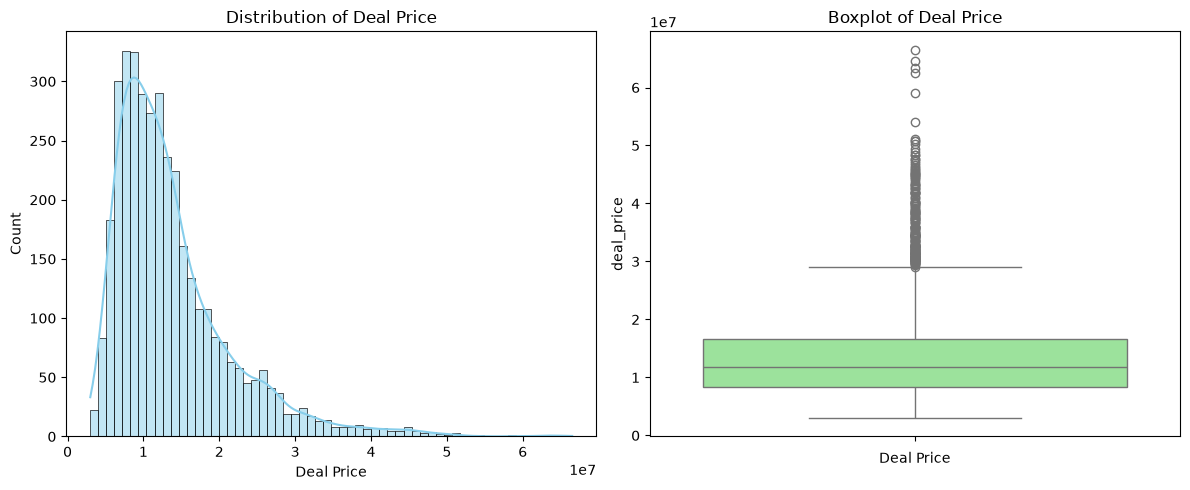

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(
    data=df_transaction['deal_price'],
    kde=True,
    color='skyblue',
    ax=axes[0]
)

axes[0].set_title('Distribution of Deal Price')
axes[0].set_xlabel('Deal Price')


# Boxplot
sns.boxplot(
    data=df_transaction['deal_price'],
    color='lightgreen',
    ax=axes[1]
)

axes[1].set_title('Boxplot of Deal Price')
axes[1].set_xlabel('Deal Price')


plt.tight_layout()
plt.show()

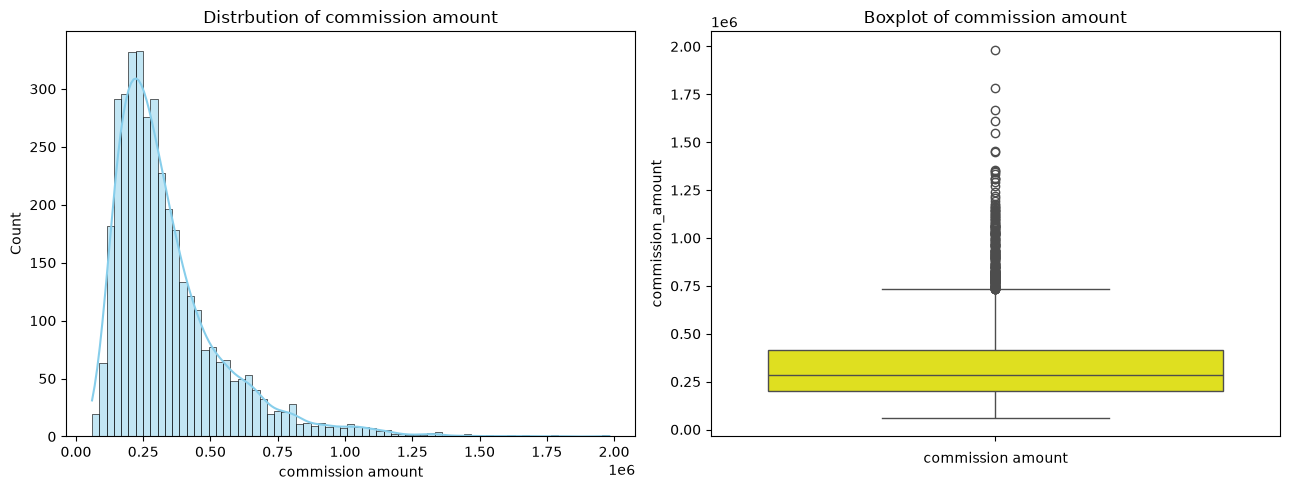

In [29]:
fig, axes = plt.subplots(1,2,figsize = (13,5))

#histogram
sns.histplot(data = df_transaction['commission_amount'],
            kde = True,
            color = 'skyblue',
            ax = axes[0]
)
axes[0].set_title('Distrbution of commission amount')
axes[0].set_xlabel('commission amount')

#Boxplot
sns.boxplot(data = df_transaction['commission_amount'],
            color = 'yellow',
            ax = axes[1]
)
axes[1].set_title('Boxplot of commission amount')
axes[1].set_xlabel('commission amount')

plt.tight_layout()
plt.show()

ANALISIS REVENUE PERFORMANCE

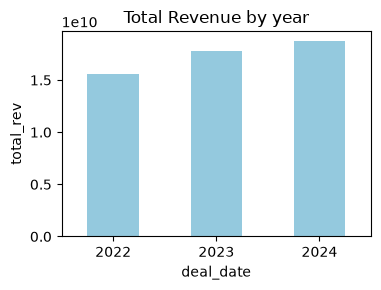

In [49]:
#total revenue tahunan
rev_year = df_transaction.groupby(
    df_transaction['deal_date'].dt.year).agg(
        total_rev = ('deal_price','sum')
    ).reset_index()

plt.figure(figsize=(4,3))
sns.barplot(data = rev_year,
             x = 'deal_date',
             y='total_rev',
             color = 'skyblue',
             width= 0.5
) 

plt.title('Total Revenue by year')

plt.tight_layout()
plt.show()
